In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from skimage.feature import graycomatrix, graycoprops

In [47]:
SIZE = 32

In [48]:
train_df = pd.read_csv(f'features/{SIZE}/train_features.csv')
valid_df = pd.read_csv(f'features/{SIZE}/valid_features.csv')

In [49]:
X_train = train_df.drop(columns=["filename", "label"])
y_train = train_df["label"]

X_test = valid_df.drop(columns=["filename", "label"])
y_test = valid_df["label"]

In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [51]:
joblib.dump(scaler, f"features/{SIZE}/grape_scaler.pkl")

['features/32/grape_scaler.pkl']

In [52]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [53]:
joblib.dump(knn, f"models/knn/{SIZE}/grape_knn.pkl")

['models/knn/32/grape_knn.pkl']

In [54]:
# Prediksi data train
y_train_pred = knn.predict(X_train_scaled)

# Prediksi data test
y_test_pred = knn.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)

test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy : 0.9146557600545331
Testing Accuracy  : 0.8613698630136987

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.77      0.80      0.78       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.94      0.95      0.95       430
                      grape leaf Healthy       0.97      0.98      0.98       435
                    grape leaf black rot       0.78      0.74      0.76       480

                                accuracy                           0.86      1825
                               macro avg       0.87      0.87      0.87      1825
                            weighted avg       0.86      0.86      0.86      1825



In [ ]:
# Cross Validation KNN
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_scores = cross_val_score(
    knn, 
    X_train_scaled, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("KNN Cross Validation Scores:")
print(f"Scores per fold: {knn_cv_scores}")
print(f"Mean CV Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {knn_cv_scores.std():.4f}")

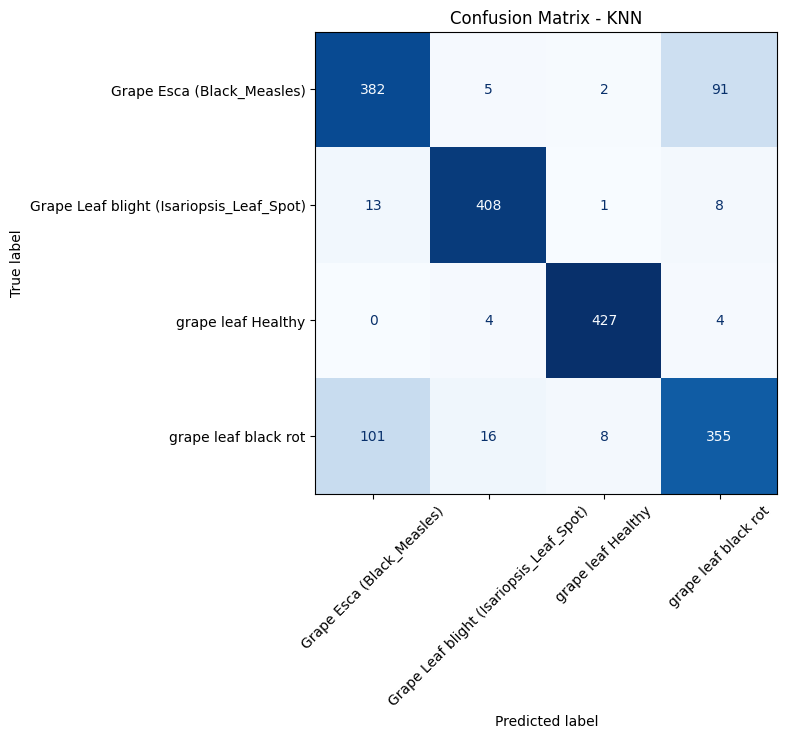

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - KNN")
plt.show()

In [56]:
le = LabelEncoder()

y_train_ann = le.fit_transform(train_df["label"])
y_test_ann = le.transform(valid_df["label"])

print(le.classes_)

print("Contoh y encoded:", y_train_ann[:5])

['Grape Esca (Black_Measles)' 'Grape Leaf blight (Isariopsis_Leaf_Spot)'
 'grape leaf Healthy' 'grape leaf black rot']
Contoh y encoded: [0 0 0 0 0]


In [57]:
joblib.dump(le, f"models/ann/{SIZE}/grape_label_encoder.pkl")

['models/ann/32/grape_label_encoder.pkl']

In [58]:
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size="auto",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)

ann.fit(X_train_scaled, y_train_ann)

Iteration 1, loss = 0.69295780
Validation score: 0.810627
Iteration 2, loss = 0.37334432
Validation score: 0.851499
Iteration 3, loss = 0.30098026
Validation score: 0.874659
Iteration 4, loss = 0.26408238
Validation score: 0.880109
Iteration 5, loss = 0.22898397
Validation score: 0.885559
Iteration 6, loss = 0.22987141
Validation score: 0.888283
Iteration 7, loss = 0.19182948
Validation score: 0.892371
Iteration 8, loss = 0.17936482
Validation score: 0.893733
Iteration 9, loss = 0.15798326
Validation score: 0.892371
Iteration 10, loss = 0.18258920
Validation score: 0.886921
Iteration 11, loss = 0.14035088
Validation score: 0.899183
Iteration 12, loss = 0.12769707
Validation score: 0.904632
Iteration 13, loss = 0.11662330
Validation score: 0.903270
Iteration 14, loss = 0.10802737
Validation score: 0.911444
Iteration 15, loss = 0.09935976
Validation score: 0.914169
Iteration 16, loss = 0.09137990
Validation score: 0.910082
Iteration 17, loss = 0.08367258
Validation score: 0.912807
Iterat

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=300,
              n_iter_no_change=20, random_state=42, verbose=True)

In [59]:
joblib.dump(ann, f"models/ann/{SIZE}/grape_mlp.pkl")

['models/ann/32/grape_mlp.pkl']

In [60]:
y_train_pred_ann = ann.predict(X_train_scaled)
y_test_pred_ann = ann.predict(X_test_scaled)

train_acc_ann = accuracy_score(
    y_train_ann,
    y_train_pred_ann
)

test_acc_ann = accuracy_score(
    y_test_ann,
    y_test_pred_ann
)

print("Training Accuracy:", train_acc_ann)
print("Testing Accuracy :", test_acc_ann)

print("\nClassification Report:\n")
print(classification_report(y_test_ann, y_test_pred_ann, target_names=le.classes_))

Training Accuracy: 0.9856850715746421
Testing Accuracy : 0.9347945205479452

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.89      0.92      0.91       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.98      0.97      0.97       430
                      grape leaf Healthy       0.98      0.99      0.99       435
                    grape leaf black rot       0.89      0.87      0.88       480

                                accuracy                           0.93      1825
                               macro avg       0.94      0.94      0.94      1825
                            weighted avg       0.93      0.93      0.93      1825



In [ ]:
# Cross Validation MLP
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlp_cv_scores = cross_val_score(
    ann, 
    X_train_scaled, 
    y_train_ann, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("MLP Cross Validation Scores:")
print(f"Scores per fold: {mlp_cv_scores}")
print(f"Mean CV Accuracy: {mlp_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {mlp_cv_scores.std():.4f}")

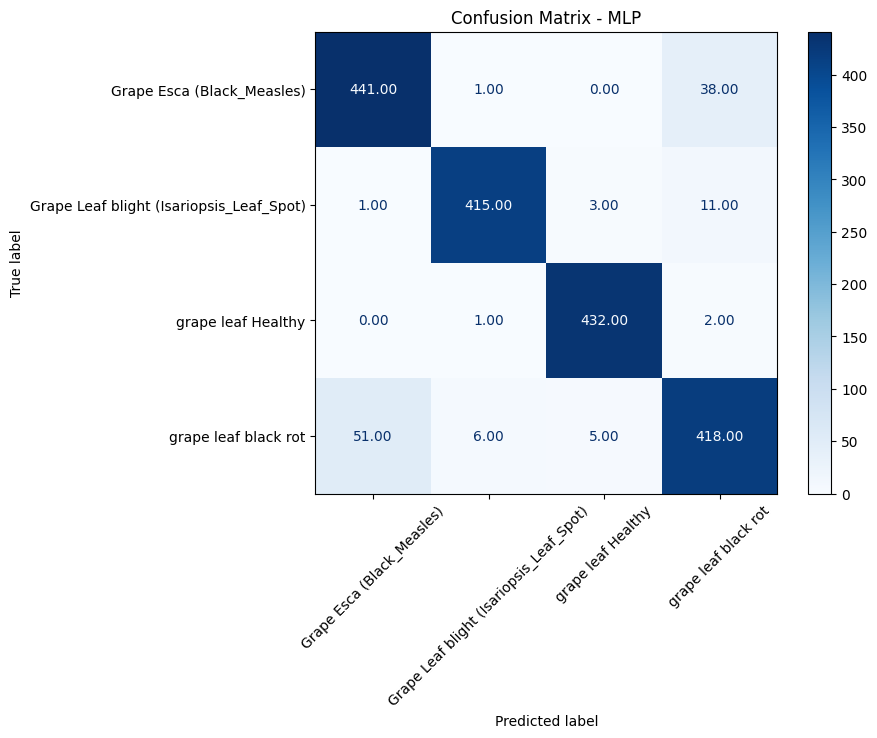

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_norm = confusion_matrix(
    y_test_ann,
    y_test_pred_ann
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - MLP")
plt.show()